### Load Dataset

In [8]:
import pandas as pd

labels = pd.read_csv("dentex_train_labels.csv")
labels.head()


,image_name,label
0,train_673.png,1
1,train_283.png,1
2,train_435.png,0
3,train_95.png,1
4,train_475.png,1


In [9]:
labels.shape

(705, 2)

#### Check class balance

In [10]:
labels['label'].value_counts(normalize=True)


label
1    0.921986
0    0.078014
Name: proportion, dtype: float64

#### Split Dataset into Train, Test and Split

In [11]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    labels,
    test_size=0.3,
    stratify=labels["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)


#### Fix class-imbalance

In [ ]:
# calculates a class-imbalance weight for the positive class (label = 1) and converts it into a PyTorch tensor.

import torch

neg = (train_df["label"] == 0).sum()
pos = (train_df["label"] == 1).sum()

pos_weight = torch.tensor([neg / pos])
pos_weight


tensor([0.0835], dtype=torch.float64)

#### Get value count for train, test and val dataset

In [13]:
print(train_df["label"].value_counts())
print(val_df["label"].value_counts())
print(test_df["label"].value_counts())


label
1    455
0     38
Name: count, dtype: int64
label
1    98
0     8
Name: count, dtype: int64
label
1    97
0     9
Name: count, dtype: int64


In [14]:
import torch
from collections import Counter

class_counts = Counter(train_df["label"])
class_counts


Counter({1: 455, 0: 38})

#### Computes class weights for each label

In [15]:
num_samples = sum(class_counts.values())

class_weights = {
    cls: num_samples / count
    for cls, count in class_counts.items()
}

class_weights


{1: 1.0835164835164834, 0: 12.973684210526315}

#### Assigns a weight to every individual training sample

In [16]:
sample_weights = train_df["label"].map(class_weights).values
sample_weights = torch.DoubleTensor(sample_weights)


In [17]:
import os
print(os.getcwd())


c:\Users\nupur.sarkar\Documents\Dental_Xray_model


In [18]:
IMAGE_DIR = r"C:\Users\nupur.sarkar\Documents\Dental_Xray_model\quadrant-enumeration-disease\xrays"


In [19]:
import os
os.path.exists(IMAGE_DIR)
os.listdir(IMAGE_DIR)[:10]


['train_0.png',
 'train_1.png',
 'train_10.png',
 'train_100.png',
 'train_101.png',
 'train_102.png',
 'train_103.png',
 'train_104.png',
 'train_105.png',
 'train_106.png']

In [20]:
missing = []

for img in train_df["image_name"]:
    if not os.path.exists(os.path.join(IMAGE_DIR, img)):
        missing.append(img)

len(missing)


0

#### Image preprocessing pipeline

In [21]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


#### Dataloader

In [22]:
from torch.utils.data import Dataset
from PIL import Image
import os

class DentalDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "image_name"]
        label = self.df.loc[idx, "label"]

        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
# converts data splits into PyTorch-ready datasets that can later be fed into DataLoaders.

train_ds = DentalDataset(train_df, IMAGE_DIR, transform=train_transform)
val_ds   = DentalDataset(val_df, IMAGE_DIR, transform=val_transform)
test_ds  = DentalDataset(test_df, IMAGE_DIR, transform=val_transform)


In [ ]:
#dimension of the first image tensor and its corresponding label.
img, lbl = train_ds[0]
print(img.shape, lbl)


torch.Size([3, 224, 224]) 1


#### Weighted Sampling Stratergy

In [25]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch
from collections import Counter

counts = Counter(train_df["label"])
class_weights = {cls: 1.0/count for cls, count in counts.items()}

sample_weights = train_df["label"].map(class_weights).values
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


#### Dataloaders

In [26]:
train_loader = DataLoader(
    train_ds,
    batch_size=16,
    sampler=sampler
)

val_loader = DataLoader(
    val_ds,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=16,
    shuffle=False
)


In [27]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)


torch.Size([16, 3, 224, 224]) torch.Size([16])


#### Loaded pretrained ResNet-18

In [28]:
import torch.nn as nn
from torchvision import models
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze backbone (important for small datasets)
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
model.fc = nn.Linear(model.fc.in_features, 1)

model = model.to(device)


#### Configures a class-imbalance-aware loss function

In [29]:
pos_weight = torch.tensor(
    [counts[0] / counts[1]],
    device=device
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


#### Create an Optimizer

In [ ]:
# creates an optimizer that updates only the final classification layer of your model using the Adam optimization algorithm with a learning rate of 0.001.
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)      #compute loss

        loss.backward()
        optimizer.step()                       #backprop and update

        total_loss += loss.item()

    return total_loss / len(loader)            #return average loss for the epoch


def evaluate(model, loader):
    model.eval()                               #evaluation mode
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)            #forward pass
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()        #apply threshold to get binary predictions

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    #compute metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)

    return acc, prec, rec


In [32]:
EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_acc, val_prec, val_rec = evaluate(model, val_loader)

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.3f} | "
        f"Val Prec: {val_prec:.3f} | "
        f"Val Recall: {val_rec:.3f}"
    )


Epoch 1 | Loss: 0.1752 | Val Acc: 0.075 | Val Prec: 0.000 | Val Recall: 0.000
Epoch 2 | Loss: 0.1386 | Val Acc: 0.075 | Val Prec: 0.000 | Val Recall: 0.000
Epoch 3 | Loss: 0.1415 | Val Acc: 0.075 | Val Prec: 0.000 | Val Recall: 0.000
Epoch 4 | Loss: 0.1334 | Val Acc: 0.075 | Val Prec: 0.000 | Val Recall: 0.000
Epoch 5 | Loss: 0.1386 | Val Acc: 0.075 | Val Prec: 0.000 | Val Recall: 0.000


In [33]:
model.eval()

images, labels = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    probs = torch.sigmoid(outputs)

probs[:10].cpu().numpy(), labels[:10].numpy()


(array([[0.03778177],
        [0.08682423],
        [0.16026808],
        [0.09880479],
        [0.04388433],
        [0.1388739 ],
        [0.0884966 ],
        [0.11187744],
        [0.06654943],
        [0.31891733]], dtype=float32),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))

#### Freeze the Network

In [34]:
# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last ResNet block + classifier
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True


In [35]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)


In [36]:
preds = (probs > 0.3).int()


In [37]:
EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_acc, val_prec, val_rec = evaluate(model, val_loader)

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.3f} | "
        f"Val Prec: {val_prec:.3f} | "
        f"Val Recall: {val_rec:.3f}"
    )


Epoch 1 | Loss: 0.0892 | Val Acc: 0.651 | Val Prec: 0.955 | Val Recall: 0.653
Epoch 2 | Loss: 0.0335 | Val Acc: 0.792 | Val Prec: 0.952 | Val Recall: 0.816
Epoch 3 | Loss: 0.0131 | Val Acc: 0.906 | Val Prec: 0.940 | Val Recall: 0.959
Epoch 4 | Loss: 0.0069 | Val Acc: 0.887 | Val Prec: 0.922 | Val Recall: 0.959
Epoch 5 | Loss: 0.0068 | Val Acc: 0.906 | Val Prec: 0.923 | Val Recall: 0.980
Epoch 6 | Loss: 0.0033 | Val Acc: 0.906 | Val Prec: 0.923 | Val Recall: 0.980
Epoch 7 | Loss: 0.0027 | Val Acc: 0.896 | Val Prec: 0.922 | Val Recall: 0.969
Epoch 8 | Loss: 0.0020 | Val Acc: 0.906 | Val Prec: 0.923 | Val Recall: 0.980
Epoch 9 | Loss: 0.0223 | Val Acc: 0.925 | Val Prec: 0.925 | Val Recall: 1.000
Epoch 10 | Loss: 0.0149 | Val Acc: 0.792 | Val Prec: 0.952 | Val Recall: 0.816


In [ ]:
#Trains the model for multiple epochs
#Evaluates it on the validation set after each epoch
#Keeps track of the best Recall score
#Saves the model checkpoint whenever Recall improves

best_recall = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_acc, val_prec, val_rec = evaluate(model, val_loader)

    if val_rec > best_recall:
        best_recall = val_rec
        torch.save(model.state_dict(), "best_caries_model.pt")

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.3f} | "
        f"Val Prec: {val_prec:.3f} | "
        f"Val Recall: {val_rec:.3f}"
    )


Epoch 1 | Loss: 0.0039 | Val Acc: 0.858 | Val Prec: 0.919 | Val Recall: 0.929
Epoch 2 | Loss: 0.0020 | Val Acc: 0.906 | Val Prec: 0.923 | Val Recall: 0.980
Epoch 3 | Loss: 0.0021 | Val Acc: 0.906 | Val Prec: 0.923 | Val Recall: 0.980
Epoch 4 | Loss: 0.0020 | Val Acc: 0.906 | Val Prec: 0.923 | Val Recall: 0.980
Epoch 5 | Loss: 0.0069 | Val Acc: 0.906 | Val Prec: 0.923 | Val Recall: 0.980
Epoch 6 | Loss: 0.0019 | Val Acc: 0.877 | Val Prec: 0.929 | Val Recall: 0.939
Epoch 7 | Loss: 0.0008 | Val Acc: 0.896 | Val Prec: 0.922 | Val Recall: 0.969
Epoch 8 | Loss: 0.0012 | Val Acc: 0.906 | Val Prec: 0.923 | Val Recall: 0.980
Epoch 9 | Loss: 0.0005 | Val Acc: 0.906 | Val Prec: 0.923 | Val Recall: 0.980
Epoch 10 | Loss: 0.0011 | Val Acc: 0.906 | Val Prec: 0.923 | Val Recall: 0.980


In [39]:
torch.save(model.state_dict(), "final_caries_resnet18.pt")


#### Testing

In [40]:
model.load_state_dict(torch.load("final_caries_resnet18.pt"))
test_acc, test_prec, test_rec = evaluate(model, test_loader)

print("TEST SET RESULTS")
print(f"Accuracy : {test_acc:.3f}")
print(f"Precision: {test_prec:.3f}")
print(f"Recall   : {test_rec:.3f}")


TEST SET RESULTS
Accuracy : 0.906
Precision: 0.914
Recall   : 0.990


#### Confusion Matrix

In [41]:
from sklearn.metrics import confusion_matrix

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.3).int()

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

confusion_matrix(y_true, y_pred)


array([[ 0,  9],
       [ 0, 97]])

In [42]:
import pandas as pd

labels = pd.read_csv("dentex_train_labels.csv")
labels.head()


,image_name,label
0,train_673.png,1
1,train_283.png,1
2,train_435.png,0
3,train_95.png,1
4,train_475.png,1


In [43]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve

model.eval()

y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)

        y_scores.extend(probs.cpu().numpy().ravel())
        y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores)


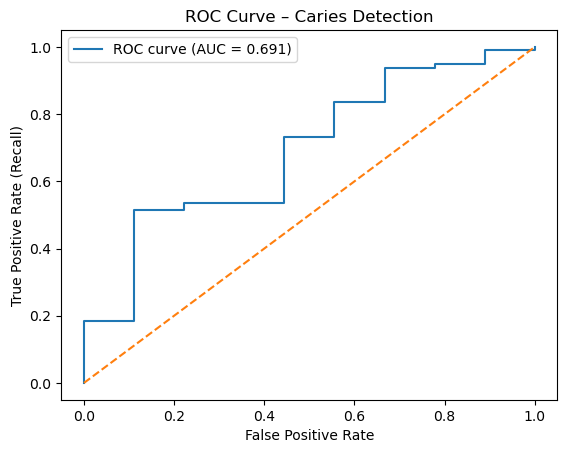

In [44]:
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve – Caries Detection")
plt.legend()
plt.show()


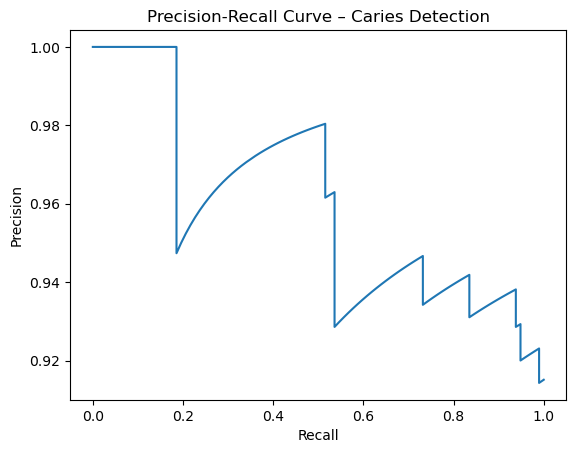

In [45]:
precision, recall, _ = precision_recall_curve(y_true, y_scores)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Caries Detection")
plt.show()


#### Grad-Cam Analysis

In [46]:
%pip install grad-cam



Note: you may need to restart the kernel to use updated packages.


In [47]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
import cv2


In [48]:
target_layers = [model.layer4[-1]]


In [49]:
img_tensor, label = test_ds[0]

input_tensor = img_tensor.unsqueeze(0).to(device)

# Convert tensor → numpy image
rgb_img = img_tensor.permute(1, 2, 0).cpu().numpy()
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())


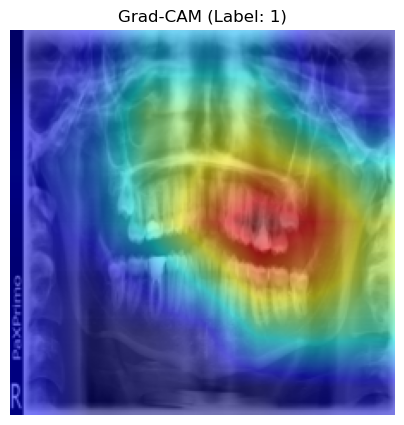

In [50]:
cam = GradCAM(model=model, target_layers=target_layers)

targets = [BinaryClassifierOutputTarget(1)]  # caries class

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)[0]

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(5,5))
plt.imshow(visualization)
plt.axis("off")
plt.title(f"Grad-CAM (Label: {label})")
plt.show()


### Training on EfficientNet-B0

In [51]:
import torch
import torch.nn as nn
import torchvision.models as models
model = models.efficientnet_b0(pretrained=True)


c:\Users\nupur.sarkar\AppData\Local\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\nupur.sarkar\AppData\Local\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\nupur.sarkar/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:06<00:00, 3.13MB/s]


In [52]:
in_features = model.classifier[1].in_features

model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 1)  # binary output
)


In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [54]:
criterion = nn.BCEWithLogitsLoss()


In [55]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


In [56]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np

def evaluate(model, loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds.extend((probs > 0.5).astype(int))
            targets.extend(labels.cpu().numpy())

    return (
        accuracy_score(targets, preds),
        precision_score(targets, preds, zero_division=0),
        recall_score(targets, preds)
    )


In [58]:
EPOCHS = 15
best_recall = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_acc, val_prec, val_rec = evaluate(model, val_loader)

    if val_rec > best_recall:
        best_recall = val_rec
        torch.save(model.state_dict(), "best_efficientnet_caries.pt")

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.3f} | "
        f"Val Prec: {val_prec:.3f} | "
        f"Val Recall: {val_rec:.3f}"
    )


Epoch 1 | Loss: 0.6325 | Val Acc: 0.623 | Val Prec: 0.939 | Val Recall: 0.633
Epoch 2 | Loss: 0.4465 | Val Acc: 0.849 | Val Prec: 0.946 | Val Recall: 0.888
Epoch 3 | Loss: 0.2640 | Val Acc: 0.915 | Val Prec: 0.949 | Val Recall: 0.959
Epoch 4 | Loss: 0.1334 | Val Acc: 0.925 | Val Prec: 0.950 | Val Recall: 0.969
Epoch 5 | Loss: 0.0857 | Val Acc: 0.915 | Val Prec: 0.941 | Val Recall: 0.969
Epoch 6 | Loss: 0.0884 | Val Acc: 0.896 | Val Prec: 0.922 | Val Recall: 0.969
Epoch 7 | Loss: 0.0559 | Val Acc: 0.896 | Val Prec: 0.922 | Val Recall: 0.969
Epoch 8 | Loss: 0.0675 | Val Acc: 0.906 | Val Prec: 0.923 | Val Recall: 0.980
Epoch 9 | Loss: 0.0613 | Val Acc: 0.906 | Val Prec: 0.931 | Val Recall: 0.969
Epoch 10 | Loss: 0.0241 | Val Acc: 0.915 | Val Prec: 0.924 | Val Recall: 0.990
Epoch 11 | Loss: 0.0234 | Val Acc: 0.906 | Val Prec: 0.931 | Val Recall: 0.969
Epoch 12 | Loss: 0.0448 | Val Acc: 0.915 | Val Prec: 0.932 | Val Recall: 0.980
Epoch 13 | Loss: 0.0320 | Val Acc: 0.906 | Val Prec: 0.931 | 

In [59]:
model.load_state_dict(torch.load("best_efficientnet_caries.pt"))
test_acc, test_prec, test_rec = evaluate(model, test_loader)

print("TEST SET RESULTS")
print(f"Accuracy : {test_acc:.3f}")
print(f"Precision: {test_prec:.3f}")
print(f"Recall   : {test_rec:.3f}")

TEST SET RESULTS
Accuracy : 0.915
Precision: 0.915
Recall   : 1.000


In [60]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


In [61]:
def get_probs_and_labels(model, loader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()

            all_probs.extend(probs.flatten())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_probs), np.array(all_labels)


In [62]:
y_probs, y_true = get_probs_and_labels(model, test_loader)


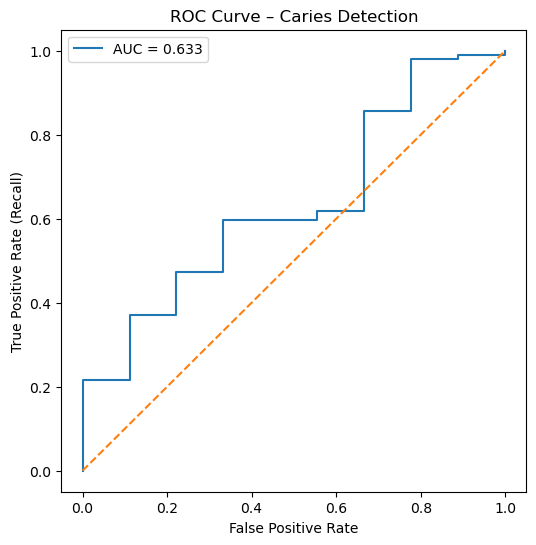

In [63]:
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve – Caries Detection")
plt.legend()
plt.show()


In [65]:
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, thresholds = precision_recall_curve(y_true, y_probs)
ap_score = average_precision_score(y_true, y_probs)



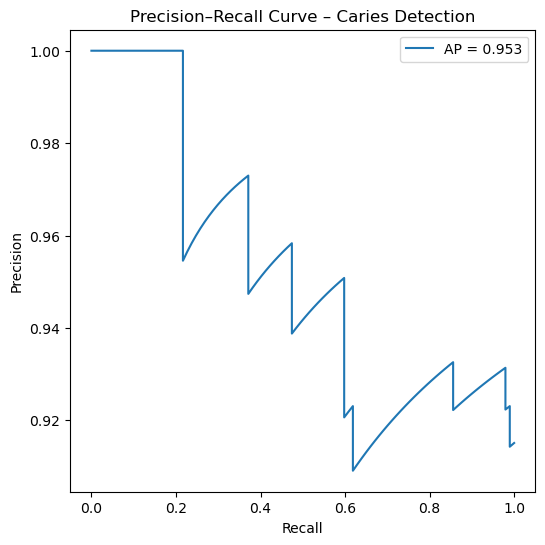

In [66]:
plt.figure(figsize=(6, 6))
plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Caries Detection")
plt.legend()
plt.show()


In [67]:
model_b1 = models.efficientnet_b1(pretrained=True)


c:\Users\nupur.sarkar\AppData\Local\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\nupur.sarkar\AppData\Local\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B1_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to C:\Users\nupur.sarkar/.cache\torch\hub\checkpoints\efficientnet_b1_rwightman-bac287d4.pth


100%|██████████| 30.1M/30.1M [00:08<00:00, 3.82MB/s]


In [68]:
in_features = model_b1.classifier[1].in_features

model_b1.classifier[1] = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 1)
)

model_b1 = model_b1.to(device)


In [69]:
train_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [72]:
train_ds = DentalDataset(train_df, IMAGE_DIR, transform=train_transform)
val_ds   = DentalDataset(val_df, IMAGE_DIR, transform=val_transform)
test_ds  = DentalDataset(test_df, IMAGE_DIR, transform=val_transform)


In [73]:
from torch.utils.data import DataLoader, WeightedRandomSampler
sample_weights = train_df["label"].map(class_weights).values
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


In [74]:
train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)


In [75]:
criterion = nn.BCEWithLogitsLoss()


In [76]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=8e-5,           # slightly LOWER than B0
    weight_decay=1e-4
)


In [77]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np
def evaluate(model, loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds.extend((probs > 0.5).astype(int))
            targets.extend(labels.cpu().numpy())

    return (
        accuracy_score(targets, preds),
        precision_score(targets, preds, zero_division=0),
        recall_score(targets, preds)
    )


In [79]:
EPOCHS = 12
best_recall = 0
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_acc, val_prec, val_rec = evaluate(model, val_loader)

    if val_rec > best_recall:
        best_recall = val_rec
        torch.save(model.state_dict(), "best_efficientnet_b1.pt")

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.3f} | "
        f"Val Prec: {val_prec:.3f} | "
        f"Val Recall: {val_rec:.3f}"
    )


Epoch 1 | Loss: 0.1515 | Val Acc: 0.764 | Val Prec: 0.940 | Val Recall: 0.796
Epoch 2 | Loss: 0.1261 | Val Acc: 0.906 | Val Prec: 0.923 | Val Recall: 0.980
Epoch 3 | Loss: 0.0913 | Val Acc: 0.906 | Val Prec: 0.923 | Val Recall: 0.980
Epoch 4 | Loss: 0.0969 | Val Acc: 0.896 | Val Prec: 0.931 | Val Recall: 0.959
Epoch 5 | Loss: 0.0645 | Val Acc: 0.915 | Val Prec: 0.924 | Val Recall: 0.990
Epoch 6 | Loss: 0.0454 | Val Acc: 0.906 | Val Prec: 0.931 | Val Recall: 0.969
Epoch 7 | Loss: 0.0509 | Val Acc: 0.896 | Val Prec: 0.922 | Val Recall: 0.969
Epoch 8 | Loss: 0.0473 | Val Acc: 0.906 | Val Prec: 0.923 | Val Recall: 0.980
Epoch 9 | Loss: 0.1030 | Val Acc: 0.906 | Val Prec: 0.923 | Val Recall: 0.980
Epoch 10 | Loss: 0.0518 | Val Acc: 0.887 | Val Prec: 0.922 | Val Recall: 0.959
Epoch 11 | Loss: 0.0343 | Val Acc: 0.915 | Val Prec: 0.924 | Val Recall: 0.990
Epoch 12 | Loss: 0.0329 | Val Acc: 0.877 | Val Prec: 0.921 | Val Recall: 0.949


### Fine - Tuning

In [ ]:
# Load pretrained EfficientNet-B1 and modify the classifier for binary output

import torchvision.models as models
import torch.nn as nn

model = models.efficientnet_b1(weights="IMAGENET1K_V1")

# Replace classifier
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features, 1
)


In [ ]:
# freeze everything
for param in model.parameters():
    param.requires_grad = False


In [82]:
# unfreeze last 2 blocks + classifier

for param in model.features[-2:].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True


In [83]:
# optimizer with small LR
import torch.optim as optim

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,          # VERY IMPORTANT
    weight_decay=1e-4
)


In [84]:
#Loss
criterion = nn.BCEWithLogitsLoss()


In [85]:
# fine-tuning training loop

EPOCHS = 8
best_recall = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_acc, val_prec, val_rec = evaluate(model, val_loader)

    if val_rec > best_recall:
        best_recall = val_rec
        torch.save(model.state_dict(), "best_efficientnet_finetuned.pt")

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.3f} | "
        f"Val Prec: {val_prec:.3f} | "
        f"Val Recall: {val_rec:.3f}"
    )


Epoch 1 | Loss: 0.6958 | Val Acc: 0.462 | Val Prec: 0.956 | Val Recall: 0.439
Epoch 2 | Loss: 0.6879 | Val Acc: 0.623 | Val Prec: 0.926 | Val Recall: 0.643
Epoch 3 | Loss: 0.6890 | Val Acc: 0.708 | Val Prec: 0.959 | Val Recall: 0.714
Epoch 4 | Loss: 0.6716 | Val Acc: 0.689 | Val Prec: 0.945 | Val Recall: 0.704
Epoch 5 | Loss: 0.6680 | Val Acc: 0.774 | Val Prec: 0.951 | Val Recall: 0.796
Epoch 6 | Loss: 0.6584 | Val Acc: 0.840 | Val Prec: 0.955 | Val Recall: 0.867
Epoch 7 | Loss: 0.6595 | Val Acc: 0.840 | Val Prec: 0.945 | Val Recall: 0.878
Epoch 8 | Loss: 0.6433 | Val Acc: 0.840 | Val Prec: 0.955 | Val Recall: 0.867


In [86]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(weights="IMAGENET1K_V1")

# Replace final FC layer
model.fc = nn.Linear(model.fc.in_features, 1)


In [87]:
for param in model.parameters():
    param.requires_grad = False


In [88]:
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True


In [89]:
import torch.optim as optim

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,          # small for fine-tuning
    weight_decay=1e-4
)


In [90]:
criterion = nn.BCEWithLogitsLoss()


In [91]:
EPOCHS = 10
best_recall = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_acc, val_prec, val_rec = evaluate(model, val_loader)

    if val_rec > best_recall:
        best_recall = val_rec
        torch.save(model.state_dict(), "best_resnet_finetuned.pt")

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.3f} | "
        f"Val Prec: {val_prec:.3f} | "
        f"Val Recall: {val_rec:.3f}"
    )


Epoch 1 | Loss: 0.7515 | Val Acc: 0.925 | Val Prec: 0.925 | Val Recall: 1.000
Epoch 2 | Loss: 0.6386 | Val Acc: 0.915 | Val Prec: 0.932 | Val Recall: 0.980
Epoch 3 | Loss: 0.6126 | Val Acc: 0.868 | Val Prec: 0.947 | Val Recall: 0.908
Epoch 4 | Loss: 0.5462 | Val Acc: 0.868 | Val Prec: 0.947 | Val Recall: 0.908
Epoch 5 | Loss: 0.5175 | Val Acc: 0.868 | Val Prec: 0.957 | Val Recall: 0.898
Epoch 6 | Loss: 0.4690 | Val Acc: 0.840 | Val Prec: 0.945 | Val Recall: 0.878
Epoch 7 | Loss: 0.3973 | Val Acc: 0.840 | Val Prec: 0.955 | Val Recall: 0.867
Epoch 8 | Loss: 0.3816 | Val Acc: 0.877 | Val Prec: 0.947 | Val Recall: 0.918
Epoch 9 | Loss: 0.3681 | Val Acc: 0.896 | Val Prec: 0.948 | Val Recall: 0.939
Epoch 10 | Loss: 0.3135 | Val Acc: 0.887 | Val Prec: 0.957 | Val Recall: 0.918


### Hyperparameter Tuning

In [3]:
import pandas as pd
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision import transforms


In [4]:
csv_path = r"C:\Users\nupur.sarkar\Documents\Dental_Xray_model\dentex_train_labels.csv"
image_dir = r"C:\Users\nupur.sarkar\Documents\Dental_Xray_model\quadrant-enumeration-disease\xrays"

df = pd.read_csv(csv_path)

print(df.head())


      image_name  label
0  train_673.png      1
1  train_283.png      1
2  train_435.png      0
3   train_95.png      1
4  train_475.png      1


In [5]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)


In [6]:
class DentalDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.loc[idx, "image_name"]
        label = self.dataframe.loc[idx, "label"]

        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [8]:
train_dataset = DentalDataset(train_df, image_dir, train_transform)
val_dataset = DentalDataset(val_df, image_dir, val_transform)


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0   # <-- CHANGE THIS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0   # <-- CHANGE THIS
)


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np

# ---------------------------
# Device
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# Model
# ---------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

# ---------------------------
# Loss
# ---------------------------
criterion = nn.BCEWithLogitsLoss()

# ---------------------------
# Optimizer
# ---------------------------
optimizer = AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

# ---------------------------
# Scheduler
# ---------------------------
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

# ---------------------------
# Training Loop
# ---------------------------
EPOCHS = 8
best_recall = 0
patience = 3
trigger = 0

for epoch in range(EPOCHS):

    # ---------------------
    # TRAINING
    # ---------------------
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------------------
    # VALIDATION
    # ---------------------
    model.eval()
    val_loss = 0
    preds = []
    true_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities > 0.5).int()

            preds.extend(predictions.cpu().numpy().flatten())
            true_labels.extend(labels.cpu().numpy().flatten())

    val_loss /= len(val_loader)

    # Convert to numpy arrays
    preds = np.array(preds)
    true_labels = np.array(true_labels)

    val_acc = accuracy_score(true_labels, preds)
    val_prec = precision_score(true_labels, preds, zero_division=0)
    val_rec = recall_score(true_labels, preds, zero_division=0)

    # Scheduler step
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    # Save best model based on recall
    if val_rec > best_recall:
        best_recall = val_rec
        torch.save(model.state_dict(), "best_resnet_finetuned.pt")
        trigger = 0
    else:
        trigger += 1

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.3f} | "
        f"Val Prec: {val_prec:.3f} | "
        f"Val Recall: {val_rec:.3f} | "
    )

    # Early stopping
    if trigger >= patience:
        print("Early stopping triggered.")
        break


Epoch 1 | Train Loss: 0.4400 | Val Loss: 0.5102 | Val Acc: 0.887 | Val Prec: 0.932 | Val Recall: 0.946 | LR: 0.000010
Epoch 2 | Train Loss: 0.3872 | Val Loss: 0.3769 | Val Acc: 0.922 | Val Prec: 0.922 | Val Recall: 1.000 | LR: 0.000010
Epoch 3 | Train Loss: 0.3498 | Val Loss: 0.3645 | Val Acc: 0.922 | Val Prec: 0.922 | Val Recall: 1.000 | LR: 0.000010
Epoch 4 | Train Loss: 0.3159 | Val Loss: 0.3350 | Val Acc: 0.922 | Val Prec: 0.922 | Val Recall: 1.000 | LR: 0.000010
Epoch 5 | Train Loss: 0.2901 | Val Loss: 0.3105 | Val Acc: 0.922 | Val Prec: 0.922 | Val Recall: 1.000 | LR: 0.000010
Early stopping triggered.


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np

# ---------------------------
# Device
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# Model
# ---------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

# ---------------------------
# Loss
# ---------------------------
criterion = nn.BCEWithLogitsLoss()

# ---------------------------
# Optimizer
# ---------------------------
optimizer = AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

# ---------------------------
# Scheduler
# ---------------------------
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

# ---------------------------
# Training Loop
# ---------------------------
EPOCHS = 8
best_recall = 0
patience = 3
trigger = 0

for epoch in range(EPOCHS):

    # ---------------------
    # TRAINING
    # ---------------------
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------------------
    # VALIDATION
    # ---------------------
    model.eval()
    val_loss = 0
    preds = []
    true_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities > 0.5).int()

            preds.extend(predictions.cpu().numpy().flatten())
            true_labels.extend(labels.cpu().numpy().flatten())

    val_loss /= len(val_loader)

    # Convert to numpy arrays
    preds = np.array(preds)
    true_labels = np.array(true_labels)

    val_acc = accuracy_score(true_labels, preds)
    val_prec = precision_score(true_labels, preds, zero_division=0)
    val_rec = recall_score(true_labels, preds, zero_division=0)

    # Scheduler step
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    # Save best model based on recall
    if val_rec > best_recall:
        best_recall = val_rec
        torch.save(model.state_dict(), "best_resnet_finetuned.pt")
        trigger = 0
    else:
        trigger += 1

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.3f} | "
        f"Val Prec: {val_prec:.3f} | "
        f"Val Recall: {val_rec:.3f} | "
    )

    # Early stopping
    if trigger >= patience:
        print("Early stopping triggered.")
        break
